In [50]:
library(tidyverse)
library(lmtest)
library(psych)

show.model <- function(mdl) IRdisplay::display_html(sjPlot::tab_model(mdl, digits=3)$knitr)

## Reading the dataset

In [26]:
df.data <- read_csv('SPIN_FINAL_DATASET_AUD.csv') %>%
    mutate(
        sex = factor(sex, c('m', 'f')),
        pd_group = factor(pd_group, c('NC', 'PD'))
    )

df.nc <- df.data %>% filter(pd_group == 'NC')
df.pd <- df.data %>% filter(pd_group == 'PD')

Rows: 42 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): sub, ses, pd_group, sex
dbl (4): age, moca, HFPTA, SNR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Descriptive statistics

### Control participants

In [27]:
summary(df.nc)

     sub                ses            pd_group sex        age       
 Length:13          Length:13          NC:13    m:7   Min.   :59.00  
 Class :character   Class :character   PD: 0    f:6   1st Qu.:68.00  
 Mode  :character   Mode  :character                  Median :72.00  
                                                      Mean   :72.77  
                                                      3rd Qu.:80.00  
                                                      Max.   :88.00  
      moca           HFPTA            SNR         
 Min.   :20.00   Min.   :14.17   Min.   : 0.1667  
 1st Qu.:25.00   1st Qu.:18.33   1st Qu.: 1.5000  
 Median :26.00   Median :20.83   Median : 2.1667  
 Mean   :26.46   Mean   :34.23   Mean   : 3.4231  
 3rd Qu.:28.00   3rd Qu.:44.17   3rd Qu.: 3.1667  
 Max.   :30.00   Max.   :86.67   Max.   :17.1667  

### Parkinson's disease participants

In [28]:
summary(df.pd)

     sub                ses            pd_group sex         age       
 Length:29          Length:29          NC: 0    m:20   Min.   :60.00  
 Class :character   Class :character   PD:29    f: 9   1st Qu.:65.00  
 Mode  :character   Mode  :character                   Median :70.00  
                                                       Mean   :68.97  
                                                       3rd Qu.:72.00  
                                                       Max.   :76.00  
      moca           HFPTA            SNR         
 Min.   :21.00   Min.   :10.00   Min.   :-0.8333  
 1st Qu.:26.00   1st Qu.:19.17   1st Qu.: 0.8333  
 Median :27.00   Median :24.17   Median : 2.1667  
 Mean   :27.03   Mean   :27.33   Mean   : 2.9023  
 3rd Qu.:28.00   3rd Qu.:30.83   3rd Qu.: 4.8333  
 Max.   :30.00   Max.   :55.83   Max.   :10.5000  

## Residualizing HFPTA from QuickSIN SNR for SPM analysis

In [30]:
mdl.hfpta <- lm(scale(SNR) ~ scale(HFPTA), df.pd)

show.model(mdl.hfpta)

scale(SNR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 0.000 
 -0.337 – 0.337 
 1.000 
 
 
 HFPTA 
 0.494 
 0.151 – 0.838 
 0.006 
 
 
 Observations 
 29 
 
 
 R 2 / R 2 adjusted 
 0.244 / 0.216

### Residuals used as outcome measure in SPM

1           2           3           4           5           6 
 2.34494571  0.94750167 -0.45878602  0.58255280 -1.28730150 -0.65812097 
          7           8           9          10          11          12 
 0.21295918 -0.32899257  0.73257887 -1.81996373 -0.34203510 -1.05214609 
         13          14          15          16          17          18 
-0.32224836  0.23993600 -0.42296556 -0.20804276 -1.29614515  0.55137710 
         19          20          21          22          23          24 
 1.43130089  1.38663678  0.03595629 -0.14989024  0.40554992  0.27575646 
         25          26          27          28          29 
-0.08034875 -0.11616922  0.05408946 -0.48576284 -0.17222230 
attr(,"scaled:center")
[1] 2.902299
attr(,"scaled:scale")
[1] 2.918713

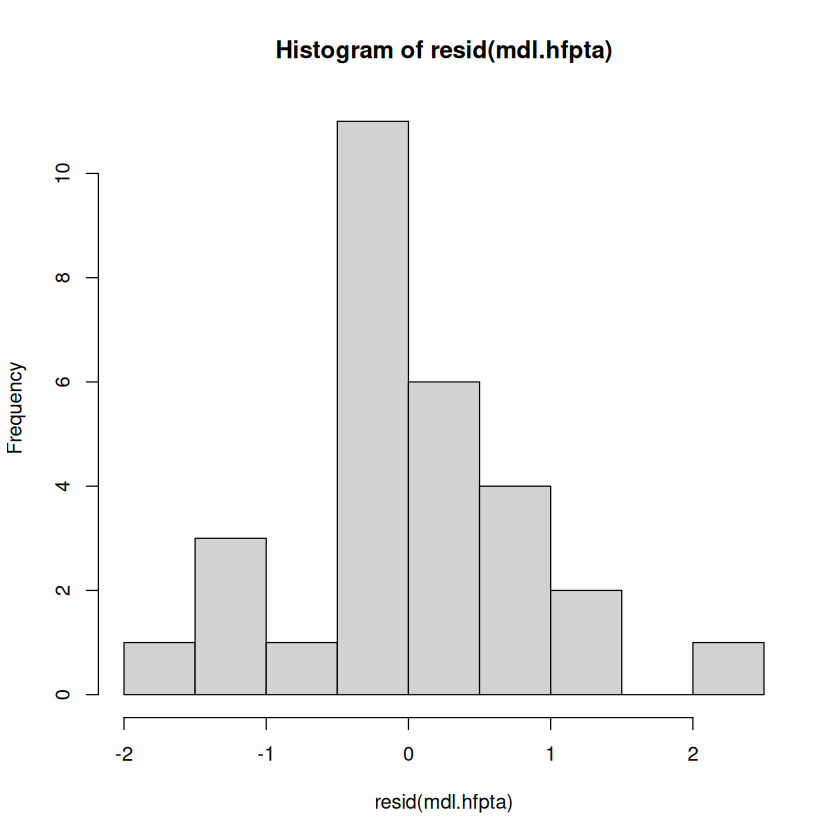

In [37]:
hist(resid(mdl.hfpta))
resid(mdl.hfpta)

## Model Comparisons

In [39]:
df.pet <- read_csv('SPIN_FINAL_DATASET_PET.csv')
df.pet.pd <- left_join(df.pd, df.pet, by=c('sub', 'ses'))
df.pet.nc <- left_join(df.nc, df.pet, by=c('sub', 'ses'))

Rows: 42 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): sub, ses
dbl (1): DVR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [43]:
mdl.pet <- lm(scale(SNR) ~ scale(HFPTA) + scale(DVR), df.pet.pd)

show.model(mdl.pet)

scale(SNR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 0.000 
 -0.272 – 0.272 
 1.000 
 
 
 HFPTA 
 0.530 
 0.253 – 0.808 
 0.001 
 
 
 DVR 
 -0.533 
 -0.811 – -0.256 
 0.001 
 
 
 Observations 
 29 
 
 
 R 2 / R 2 adjusted 
 0.528 / 0.491

In [55]:
mdl.inter <- lm(scale(SNR) ~ scale(HFPTA) * scale(DVR), df.pet.pd)

show.model(mdl.inter)

scale(SNR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 0.030 
 -0.207 – 0.267 
 0.799 
 
 
 HFPTA 
 0.722 
 0.450 – 0.994 
 <0.001 
 
 
 DVR 
 -0.444 
 -0.692 – -0.196 
 0.001 
 
 
 HFPTA × DVR 
 -0.456 
 -0.758 – -0.154 
 0.005 
 
 
 Observations 
 29 
 
 
 R 2 / R 2 adjusted 
 0.659 / 0.619

In [56]:
anova(mdl.hfpta, mdl.pet, mdl.inter)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,27,21.154940,NA,NA,NA,NA
2,26,13.223065,1,7.931875,20.797261,0.0001164505
3,25,9.534759,1,3.688306,9.670684,0.0046312913


## Model diagnostics

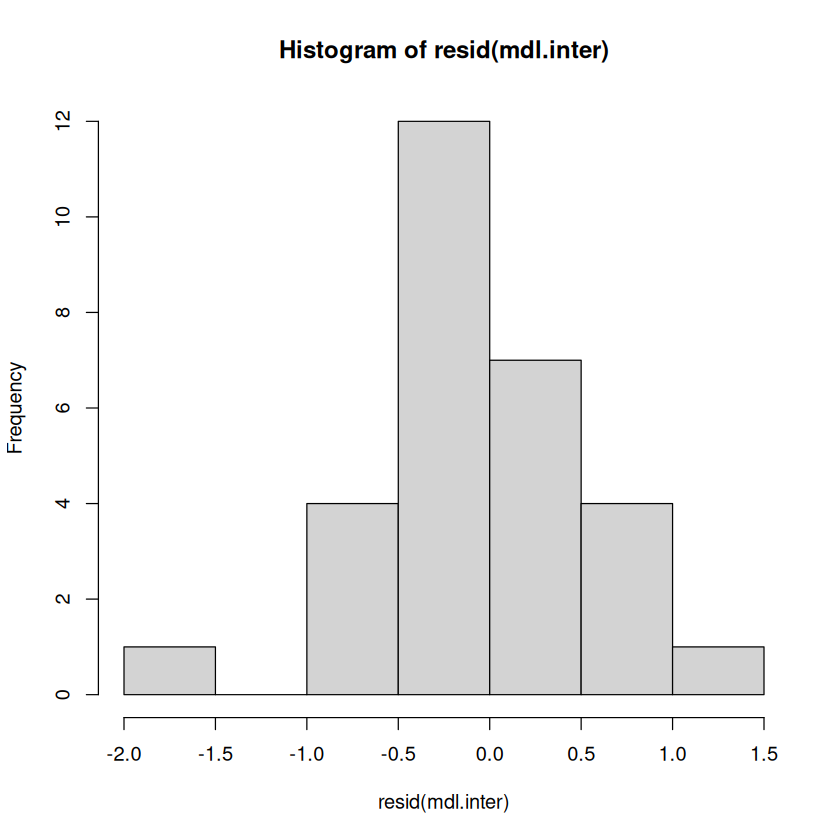

In [57]:
hist(resid(mdl.inter))

In [58]:
bptest(mdl.inter)


	studentized Breusch-Pagan test

data:  mdl.inter
BP = 1.1065, df = 3, p-value = 0.7755


In [59]:
shapiro.test(resid(mdl.inter))


	Shapiro-Wilk normality test

data:  resid(mdl.inter)
W = 0.9805, p-value = 0.8505


## Post-hoc analyses

### Correction for age and MoCA

In [62]:
mdl.covar <- update(mdl.inter, . ~ . + scale(age) + scale(moca))

show.model(mdl.covar)

scale(SNR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 0.030 
 -0.217 – 0.276 
 0.805 
 
 
 HFPTA 
 0.717 
 0.414 – 1.020 
 <0.001 
 
 
 DVR 
 -0.421 
 -0.694 – -0.148 
 0.004 
 
 
 age 
 0.066 
 -0.204 – 0.335 
 0.619 
 
 
 moca 
 0.019 
 -0.262 – 0.301 
 0.889 
 
 
 HFPTA × DVR 
 -0.456 
 -0.772 – -0.140 
 0.007 
 
 
 Observations 
 29 
 
 
 R 2 / R 2 adjusted 
 0.664 / 0.591

### Cholinergic system ANCOVA PD vs. Controls

In [76]:
df.pet.both <- rbind.data.frame(df.pet.nc, df.pet.pd)

mdl.ancova <- lm(
    scale(DVR) ~ pd_group + scale(age),
    df.pet.both
)

show.model(mdl.ancova)

scale(DVR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 0.507 
 -0.044 – 1.058 
 0.070 
 
 
 pd group [PD] 
 -0.734 
 -1.406 – -0.062 
 0.033 
 
 
 age 
 -0.272 
 -0.587 – 0.042 
 0.088 
 
 
 Observations 
 42 
 
 
 R 2 / R 2 adjusted 
 0.137 / 0.093

### Interaction Model in Controls

In [78]:
mdl.inter.nc <- lm(scale(SNR) ~ scale(HFPTA) * scale(DVR), df.pet.nc)

show.model(mdl.inter.nc)

scale(SNR) 
 
 
 Predictors 
 Estimates 
 CI 
 p 
 
 
 (Intercept) 
 -0.080 
 -0.619 – 0.458 
 0.744 
 
 
 HFPTA 
 0.755 
 -0.031 – 1.540 
 0.058 
 
 
 DVR 
 0.024 
 -0.561 – 0.609 
 0.929 
 
 
 HFPTA × DVR 
 -0.128 
 -0.715 – 0.459 
 0.633 
 
 
 Observations 
 13 
 
 
 R 2 / R 2 adjusted 
 0.704 / 0.606